# DenseNet121 — Chest X-Ray Pneumonia Classification
**Final Version | Google Colab T4 GPU**

All fixes applied:
- Real 20% validation split (no test-data leakage)
- lr_frozen=1e-4, lr_finetune=1e-5 (correct 10x ratio)
- Safe augmentation for medical X-rays
- EarlyStopping in both phases on real val_accuracy
- .cache() removed (prevents Colab RAM crash)
- batch_size=32 for stable gradients

## Cell 1 — Mount Drive & verify GPU

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Unzip dataset

In [3]:
import zipfile, os

# ── EDIT THIS PATH ──────────────────────────────────
ZIP_PATH   = '/content/drive/MyDrive/DLdataset.zip'
EXTRACT_TO = '/content/'
# ────────────────────────────────────────────────────

if not os.path.exists('/content/chest_xray'):
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)
    print('Done.')
else:
    print('Already extracted.')

TRAIN_DIR    = '/content/chest_xray/train'
VAL_DIR      = '/content/chest_xray/val'
TEST_DIR     = '/content/chest_xray/test'
COMBINED_DIR = '/content/chest_xray/train_combined'
DRIVE_SAVE   = '/content/drive/MyDrive/densenet_pneumonia_final'
os.makedirs(DRIVE_SAVE, exist_ok=True)

for split, path in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    for cls in ['NORMAL', 'PNEUMONIA']:
        n = len(os.listdir(os.path.join(path, cls)))
        print(f'  {split} / {cls}: {n} images')

Extracting...
Done.
  Train / NORMAL: 1341 images
  Train / PNEUMONIA: 3875 images
  Val / NORMAL: 8 images
  Val / PNEUMONIA: 8 images
  Test / NORMAL: 234 images
  Test / PNEUMONIA: 390 images


## Cell 3 — Import libraries

In [4]:
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras.applications import DenseNet121
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc)

print('All libraries imported successfully.')

All libraries imported successfully.


## Cell 4 — T4 GPU setup

In [5]:
mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision policy:', mixed_precision.global_policy())

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'GPU detected: {gpus[0].name}')
else:
    print('WARNING: No GPU found. Training will be very slow.')

Mixed precision policy: <DTypePolicy "mixed_float16">
GPU detected: /physical_device:GPU:0


## Cell 5 — Configuration
All tunable parameters in one place.

In [6]:
CONFIG = {
    'img_size':         (224, 224),
    'batch_size':       32,

    # Phase 1 — head only, base frozen
    'epochs_frozen':    20,
    'lr_frozen':        1e-4,

    # Phase 2 — fine-tune top DenseNet layers
    # lr_finetune MUST be 10x lower than lr_frozen
    # to avoid destroying pretrained ImageNet weights
    'epochs_finetune':  40,
    'lr_finetune':      1e-5,

    # DenseNet121 has 427 layers; 120 = last dense block
    'unfreeze_layers':  120,

    # 20% val split => ~1047 real validation images
    'val_split':        0.2,

    'seed':             42,
    'autotune':         tf.data.AUTOTUNE,
    'drive_save':       DRIVE_SAVE,
}

IMG_H, IMG_W = CONFIG['img_size']
BATCH        = CONFIG['batch_size']

print('Configuration ready.')
print(f'  img_size       : {CONFIG["img_size"]}')
print(f'  batch_size     : {BATCH}')
print(f'  lr_frozen      : {CONFIG["lr_frozen"]}')
print(f'  lr_finetune    : {CONFIG["lr_finetune"]}  (10x lower than Phase 1)')
print(f'  val_split      : {int(CONFIG["val_split"]*100)}% of combined train')
print(f'  Drive save     : {DRIVE_SAVE}')

Configuration ready.
  img_size       : (224, 224)
  batch_size     : 32
  lr_frozen      : 0.0001
  lr_finetune    : 1e-05  (10x lower than Phase 1)
  val_split      : 20% of combined train
  Drive save     : /content/drive/MyDrive/densenet_pneumonia_final


## Cell 6 — Merge original val into train
The original val set has only 8+8=16 images. We merge it into train
and create a proper 20% split from the combined data instead.

In [7]:
def merge_val_into_train(train_dir, val_dir, combined_dir):
    if os.path.exists(combined_dir):
        counts = {c: len(os.listdir(os.path.join(combined_dir, c)))
                  for c in ['NORMAL', 'PNEUMONIA']}
        print(f'Combined dir exists -> NORMAL: {counts["NORMAL"]} | PNEUMONIA: {counts["PNEUMONIA"]}')
        return counts
    for cls in ['NORMAL', 'PNEUMONIA']:
        os.makedirs(os.path.join(combined_dir, cls), exist_ok=True)
        for src_root in [train_dir, val_dir]:
            src    = os.path.join(src_root, cls)
            prefix = 'val_' if src_root == val_dir else ''
            for fname in os.listdir(src):
                shutil.copy2(os.path.join(src, fname),
                             os.path.join(combined_dir, cls, prefix + fname))
    counts = {c: len(os.listdir(os.path.join(combined_dir, c)))
              for c in ['NORMAL', 'PNEUMONIA']}
    print(f'Merged -> NORMAL: {counts["NORMAL"]} | PNEUMONIA: {counts["PNEUMONIA"]}')
    return counts

counts = merge_val_into_train(TRAIN_DIR, VAL_DIR, COMBINED_DIR)

Merged -> NORMAL: 1349 | PNEUMONIA: 3883


## Cell 7 — Class weights
PNEUMONIA (~3883) outnumbers NORMAL (~1349) by ~3:1.
Class weights force the model to treat both classes seriously.

Class weights -> NORMAL: 1.9392 | PNEUMONIA: 0.6737
Misclassifying NORMAL costs 2.9x more than PNEUMONIA


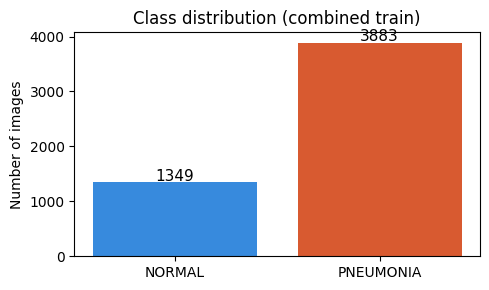

In [8]:
n_normal    = counts['NORMAL']
n_pneumonia = counts['PNEUMONIA']
labels_all  = np.array([0]*n_normal + [1]*n_pneumonia)

cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=labels_all)
class_weights = {0: float(cw[0]), 1: float(cw[1])}
print(f'Class weights -> NORMAL: {cw[0]:.4f} | PNEUMONIA: {cw[1]:.4f}')
print(f'Misclassifying NORMAL costs {cw[0]/cw[1]:.1f}x more than PNEUMONIA')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['NORMAL', 'PNEUMONIA'], [n_normal, n_pneumonia],
       color=['#378ADD', '#D85A30'])
ax.set_title('Class distribution (combined train)')
ax.set_ylabel('Number of images')
for i, v in enumerate([n_normal, n_pneumonia]):
    ax.text(i, v + 30, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE, 'class_distribution.png'), dpi=120)
plt.show()

## Cell 8 — tf.data pipeline
- Augmentation: flip + rotation + zoom only (safe for X-rays)
- Contrast/brightness excluded — alter tissue density signals
- .cache() removed — prevents Colab RAM crash
- 20% real validation split from COMBINED_DIR
- Test set is never touched during training

Found 5232 files belonging to 2 classes.
Using 4186 files for training.
Found 5232 files belonging to 2 classes.
Using 1046 files for validation.
Found 624 files belonging to 2 classes.
Train batches : 131  (~4192 images)
Val   batches : 33  (~1056 images)  [real val set]
Test  batches : 20  (~640 images)  [final eval only]


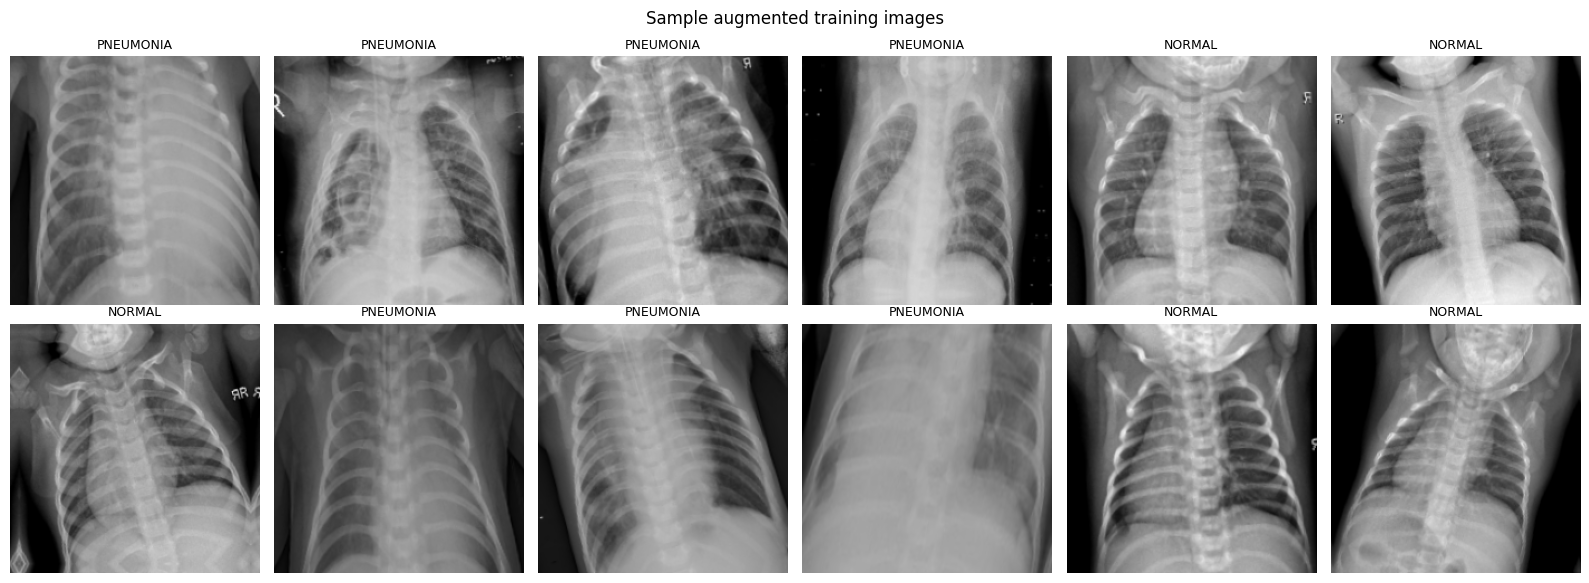

In [9]:
AUTOTUNE = CONFIG['autotune']

# Conservative augmentation for medical imaging
# Contrast/brightness intentionally excluded:
# they change tissue density appearance which is clinically meaningful
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name='augmentation')

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def preprocess_and_augment(image, label):
    image, label = preprocess(image, label)
    image = augmentation(image, training=True)
    return image, label

def make_dataset(directory, validation_split=None, subset=None,
                 augment=False, shuffle=True):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=(IMG_H, IMG_W),
        batch_size=BATCH,
        label_mode='binary',
        validation_split=validation_split,
        subset=subset,
        seed=CONFIG['seed'],
        shuffle=shuffle,
    )
    if augment:
        ds = ds.map(preprocess_and_augment, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    # No .cache() -> avoids Colab RAM crashes
    ds = ds.prefetch(AUTOTUNE)
    return ds

VAL_SPLIT = CONFIG['val_split']

train_ds = make_dataset(COMBINED_DIR, validation_split=VAL_SPLIT,
                        subset='training',   augment=True,  shuffle=True)
val_ds   = make_dataset(COMBINED_DIR, validation_split=VAL_SPLIT,
                        subset='validation', augment=False, shuffle=False)
test_ds  = make_dataset(TEST_DIR,     validation_split=None,
                        subset=None,         augment=False, shuffle=False)

print(f'Train batches : {len(train_ds)}  (~{len(train_ds)*BATCH} images)')
print(f'Val   batches : {len(val_ds)}  (~{len(val_ds)*BATCH} images)  [real val set]')
print(f'Test  batches : {len(test_ds)}  (~{len(test_ds)*BATCH} images)  [final eval only]')

sample_images, sample_labels = next(iter(train_ds))
class_names = ['NORMAL', 'PNEUMONIA']
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(np.clip(sample_images[i].numpy().astype(np.float32), 0.0, 1.0))
    ax.set_title(class_names[int(sample_labels[i])], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample augmented training images', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE, 'sample_augmented.png'), dpi=120)
plt.show()

## Cell 9 — Build DenseNet121 model

In [10]:
def build_densenet_model(trainable_base=False):
    base = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_H, IMG_W, 3),
    )
    base.trainable = trainable_base

    inputs = keras.Input(shape=(IMG_H, IMG_W, 3))
    # training=False: BN layers use stored ImageNet statistics when frozen
    x = base(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    # float32 output required for mixed precision stability
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

    return keras.Model(inputs, outputs, name='DenseNet121_Pneumonia'), base


model, base = build_densenet_model(trainable_base=False)
model.summary()

total     = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'\nTotal params     : {total:,}')
print(f'Trainable params : {trainable:,}  (head only in Phase 1)')
print(f'Frozen params    : {total - trainable:,}  (DenseNet121 base)')

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "DenseNet121_Pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,281 (27.87 MB)

 Trainable params: 265,217 (1.01 MB)

 Non-trainable params: 7,040,064 (26.86 MB)


Total params     : 7,305,281
Trainable params : 265,217  (head only in Phase 1)
Frozen params    : 7,040,064  (DenseNet121 base)


## Cell 10 — Compile helper + metrics

In [11]:
METRICS = [
    'accuracy',
    keras.metrics.AUC(name='auc'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall'),
]

def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=METRICS,
        jit_compile=True,
    )
    print(f'Model compiled | LR = {lr}')

## Cell 11 — Callbacks
Both phases monitor val_accuracy on the real 20% validation set.
EarlyStopping prevents wasted compute in both phases.

In [12]:
def get_callbacks(phase):
    ckpt_path = os.path.join(CONFIG['drive_save'], f'best_{phase}.keras')

    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=ckpt_path,
        monitor='val_accuracy',   # real val set in both phases
        save_best_only=True,
        mode='max', verbose=1,
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3, patience=4, min_lr=1e-9, verbose=1,
    )
    csv_logger = keras.callbacks.CSVLogger(
        os.path.join(CONFIG['drive_save'], f'history_{phase}.csv'),
        append=False,
    )
    # Phase 1 patience=6 (head converges fast)
    # Phase 2 patience=10 (fine-tuning needs more time)
    patience = 6 if phase == 'phase1' else 10
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=patience,
        restore_best_weights=True,
        verbose=1,
    )
    return [checkpoint, reduce_lr, csv_logger, early_stop]

## Cell 12 — Phase 1: Train head only (base frozen)
Expected time on T4: ~15–20 minutes

Watch: val_accuracy should climb steadily toward 80%+

In [13]:
print('\n' + '='*60)
print('PHASE 1: Training classification head  (base FROZEN)')
print(f'         Epochs : up to {CONFIG["epochs_frozen"]}')
print(f'         LR     : {CONFIG["lr_frozen"]}')
print(f'         Val    : real 20% split (~{len(val_ds)*BATCH} images)')
print('='*60)

compile_model(model, CONFIG['lr_frozen'])

history1 = model.fit(
    train_ds,
    epochs=CONFIG['epochs_frozen'],
    validation_data=val_ds,          # real val set -- NOT test set
    class_weight=class_weights,
    callbacks=get_callbacks('phase1'),
    verbose=1,
)

best_val = max(history1.history['val_accuracy'])
print(f'\nPhase 1 complete. Best val_accuracy: {best_val:.4f}')
print(f'Saved to: {DRIVE_SAVE}/best_phase1.keras')


PHASE 1: Training classification head  (base FROZEN)
         Epochs : up to 20
         LR     : 0.0001
         Val    : real 20% split (~1056 images)
Model compiled | LR = 0.0001
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.6498 - auc: 0.7509 - loss: 0.7003 - precision: 0.8690 - recall: 0.6142
Epoch 1: val_accuracy improved from None to 0.60707, saving model to /content/drive/MyDrive/densenet_pneumonia_final/best_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/densenet_pneumonia_final/best_phase1.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 168s 948ms/step - accuracy: 0.7286 - auc: 0.8675 - loss: 0.5397 - precision: 0.9342 - recall: 0.6801 - val_accuracy: 0.6071 - val_auc: 0.0000e+00 - val_loss: 0.8269 - val_precision: 1.0000 - val_recall: 0.6071 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.8327 - auc: 0.9526 - loss: 0.3645 - precision: 0.9789 - recall: 0.7873
Epoch 2: val_accuracy improved from 

## Cell 13 — Phase 2: Fine-tune top 120 layers
Expected time on T4: ~35–45 minutes

lr_finetune (1e-5) is 10x lower than lr_frozen (1e-4) — critical.
A high LR here would destroy pretrained ImageNet weights.

In [14]:
print('\n' + '='*60)
print(f'PHASE 2: Fine-tuning top {CONFIG["unfreeze_layers"]} DenseNet layers')
print(f'         Epochs : up to {CONFIG["epochs_finetune"]}')
print(f'         LR     : {CONFIG["lr_finetune"]}  (10x lower than Phase 1)')
print('='*60)

base.trainable = True
for layer in base.layers[:-CONFIG['unfreeze_layers']]:
    layer.trainable = False

n_trainable = sum(1 for l in base.layers if l.trainable)
print(f'Trainable base layers : {n_trainable} / {len(base.layers)}')
print(f'Frozen base layers    : {len(base.layers) - n_trainable} / {len(base.layers)}')

compile_model(model, CONFIG['lr_finetune'])

history2 = model.fit(
    train_ds,
    epochs=CONFIG['epochs_finetune'],
    validation_data=val_ds,          # same real val set
    class_weight=class_weights,
    callbacks=get_callbacks('phase2'),
    verbose=1,
)

best_val2 = max(history2.history['val_accuracy'])
print(f'\nPhase 2 complete. Best val_accuracy: {best_val2:.4f}')
print(f'Saved to: {DRIVE_SAVE}/best_phase2.keras')


PHASE 2: Fine-tuning top 120 DenseNet layers
         Epochs : up to 40
         LR     : 1e-05  (10x lower than Phase 1)
Trainable base layers : 120 / 427
Frozen base layers    : 307 / 427
Model compiled | LR = 1e-05
Epoch 1/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.9042 - auc: 0.9607 - loss: 0.2695 - precision: 0.9775 - recall: 0.9047
Epoch 1: val_accuracy improved from None to 0.90057, saving model to /content/drive/MyDrive/densenet_pneumonia_final/best_phase2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/densenet_pneumonia_final/best_phase2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.9161 - auc: 0.9695 - loss: 0.2430 - precision: 0.9746 - recall: 0.9112 - val_accuracy: 0.9006 - val_auc: 0.0000e+00 - val_loss: 0.3025 - val_precision: 1.0000 - val_recall: 0.9006 - learning_rate: 1.0000e-05
Epoch 2/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.9270 - auc: 0.9835 - loss: 0.1962 - precision: 0.9766 - recall: 0.9224
Epo

## Cell 14 — Final evaluation on test set
Test set is used here for the FIRST TIME.
It was never seen during training or validation.

In [15]:
print('\n' + '='*60)
print('FINAL EVALUATION on Test Set')
print('(Test set used for the first time here)')
print('='*60)

best_model_path = os.path.join(DRIVE_SAVE, 'best_phase2.keras')
model = keras.models.load_model(best_model_path)
print(f'Loaded: {best_model_path}\n')

results = model.evaluate(test_ds, verbose=1)
print('\nTest Set Metrics:')
print('-' * 32)
for name, val in zip(['loss','accuracy','auc','precision','recall'], results):
    print(f'  {name:12s}: {val:.4f}')

y_pred_prob, y_true = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0).flatten()
    y_pred_prob.extend(preds)
    y_true.extend(labels.numpy().flatten().astype(int))

y_pred_prob = np.array(y_pred_prob)
y_true      = np.array(y_true)
y_pred      = (y_pred_prob > 0.5).astype(int)

print('\nClassification Report:')
print(classification_report(y_true, y_pred,
      target_names=['NORMAL', 'PNEUMONIA']))


FINAL EVALUATION on Test Set
(Test set used for the first time here)
Loaded: /content/drive/MyDrive/densenet_pneumonia_final/best_phase2.keras

20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 809ms/step - accuracy: 0.9087 - auc: 0.9585 - loss: 0.3060 - precision: 0.8993 - recall: 0.9615

Test Set Metrics:
--------------------------------
  loss        : 0.3060
  accuracy    : 0.9087
  auc         : 0.9585
  precision   : 0.8993
  recall      : 0.9615

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.93      0.82      0.87       234
   PNEUMONIA       0.90      0.96      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624



## Cell 15 — Training curves, confusion matrix, ROC curve

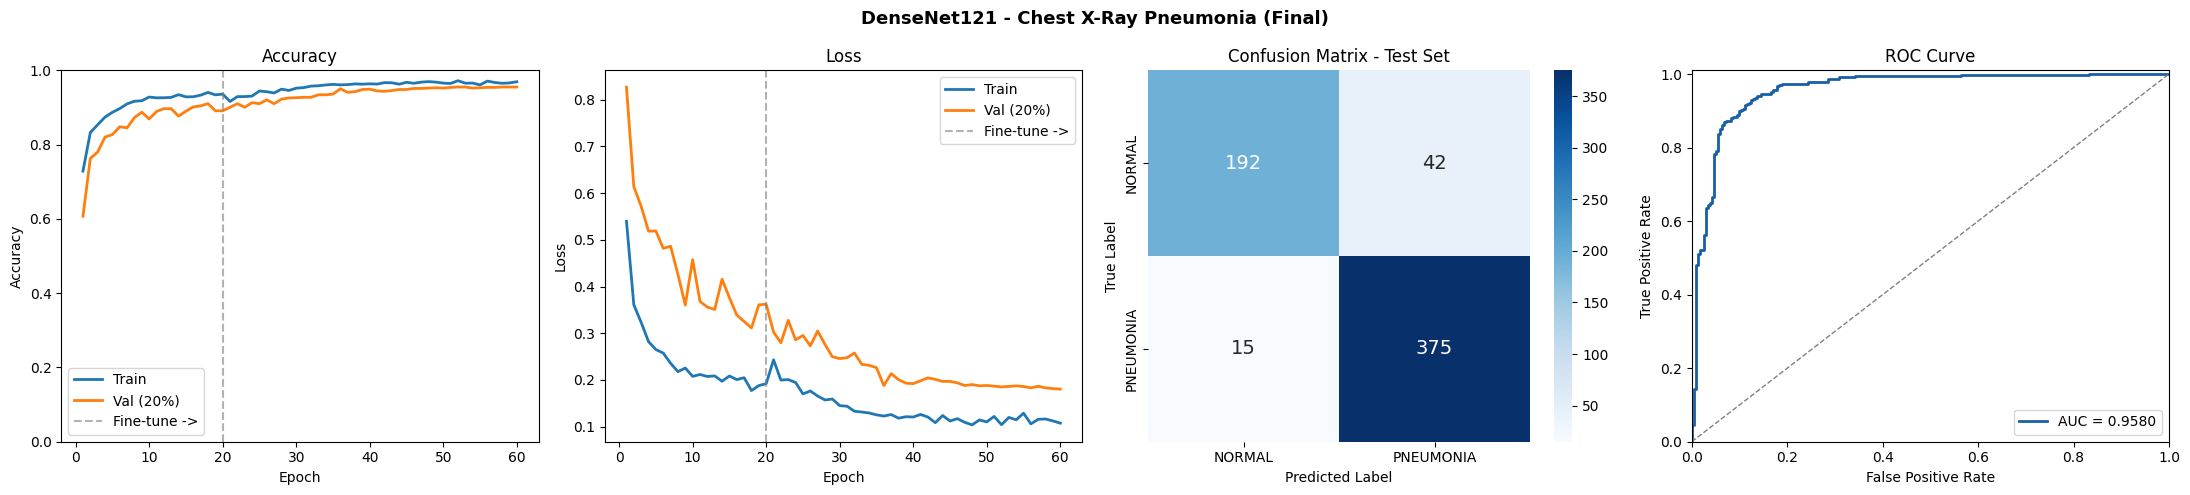

Plot saved -> /content/drive/MyDrive/densenet_pneumonia_final/final_results.png


In [16]:
def cat(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

e1 = len(history1.history['accuracy'])
e2 = len(history2.history['accuracy'])
x  = list(range(1, e1 + e2 + 1))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('DenseNet121 - Chest X-Ray Pneumonia (Final)',
             fontsize=13, fontweight='bold')

axes[0].plot(x, cat(history1, history2, 'accuracy'),     label='Train', lw=2)
axes[0].plot(x, cat(history1, history2, 'val_accuracy'), label='Val (20%)', lw=2)
axes[0].axvline(e1, color='gray', linestyle='--', alpha=0.6, label='Fine-tune ->')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])

axes[1].plot(x, cat(history1, history2, 'loss'),     label='Train', lw=2)
axes[1].plot(x, cat(history1, history2, 'val_loss'), label='Val (20%)', lw=2)
axes[1].axvline(e1, color='gray', linestyle='--', alpha=0.6, label='Fine-tune ->')
axes[1].set_title('Loss'); axes[1].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['NORMAL','PNEUMONIA'],
            yticklabels=['NORMAL','PNEUMONIA'],
            annot_kws={'size': 14})
axes[2].set_title('Confusion Matrix - Test Set')
axes[2].set_ylabel('True Label'); axes[2].set_xlabel('Predicted Label')

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)
axes[3].plot(fpr, tpr, color='#185FA5', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[3].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[3].set_title('ROC Curve'); axes[3].legend(loc='lower right')
axes[3].set_xlabel('False Positive Rate')
axes[3].set_ylabel('True Positive Rate')
axes[3].set_xlim([0, 1]); axes[3].set_ylim([0, 1.01])

plt.tight_layout()
plot_path = os.path.join(DRIVE_SAVE, 'final_results.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved -> {plot_path}')

## Cell 16 — Save final model to Google Drive

In [17]:
final_path = os.path.join(DRIVE_SAVE, 'densenet121_final.keras')
model.save(final_path)
print(f'Final model saved -> {final_path}')

saved_model_path = os.path.join(DRIVE_SAVE, 'densenet121_savedmodel')
model.export(saved_model_path)
print(f'SavedModel exported -> {saved_model_path}')

print('\n' + '='*60)
print('ALL DONE!')
print(f'Files saved at: {DRIVE_SAVE}')
print('  best_phase1.keras        -- best head-only checkpoint')
print('  best_phase2.keras        -- best fine-tuned checkpoint')
print('  densenet121_final.keras  -- final model')
print('  densenet121_savedmodel/  -- SavedModel format')
print('  final_results.png        -- all evaluation plots')
print('  class_distribution.png  -- class balance chart')
print('  sample_augmented.png    -- augmented image samples')
print('  history_phase1.csv      -- Phase 1 epoch log')
print('  history_phase2.csv      -- Phase 2 epoch log')
print('='*60)

Final model saved -> /content/drive/MyDrive/densenet_pneumonia_final/densenet121_final.keras
Saved artifact at '/content/drive/MyDrive/densenet_pneumonia_final/densenet121_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140638382561552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140638377069648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140638377069072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140638377067344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140638377074640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140638377071376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140638377072528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140638377073680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140638

## Cell 17 — (Optional) Predict on a single image

In [19]:
def predict_single_image(img_path, model, img_size=(224, 224)):
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    arr = tf.keras.utils.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    prob       = model.predict(arr, verbose=0)[0][0]
    label      = 'PNEUMONIA' if prob > 0.5 else 'NORMAL'
    confidence = prob if prob > 0.5 else 1 - prob

    color = 'red' if label == 'PNEUMONIA' else 'green'
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f'Prediction: {label}\nConfidence: {confidence*100:.1f}%',
              fontsize=12, fontweight='bold', color=color)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'Result     : {label}')
    print(f'Confidence : {confidence*100:.2f}%')
    return label, float(confidence)

# Uncomment and edit path to test on any image:
# predict_single_image(
#     '/content/chest_xray/test/PNEUMONIA/person1_bacteria_1.jpeg',
#     model
# )